<a href="https://colab.research.google.com/github/SachinRShenoy/LSTM-Based-Lithium-Ion-Battery-State-of-Health-SOH-Regression/blob/main/Classification_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# [CELL 1]
import os
import scipy.io as sio
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive', force_remount=True)

# 2. Configuration (Targeting your exact root directory)
DATA_PATH = '/content/drive/MyDrive/'
PROJECT_SAVE = '/content/drive/MyDrive/CWRU_Project/'
os.makedirs(PROJECT_SAVE, exist_ok=True)

CHUNK_SIZE = 1024

# Strict mapping to your requested output strings
LABEL_MAP = {
    0: "normal vibration",
    1: '0.007" vibration defect',
    2: '0.014" vibration defect',
    3: '0.021" vibration defect',
    4: '0.028" vibration defect'
}

Mounted at /content/drive


In [ ]:
# [CELL 2]
# File mapping directly to your uploaded filenames
FILES_1797RPM = {
    'normal': ('1797_N.mat', 0),
    'IR007':  ('1797_0.007.mat', 1),
    'IR014':  ('1797_0.014.mat', 2),
    'IR021':  ('1797_0.021.mat', 3),
    'IR028':  ('1797_0.028.mat', 4)
}

def extract_chunks(sig, label, chunk_size=CHUNK_SIZE):
    n = len(sig) // chunk_size
    chunks = sig[:n * chunk_size].reshape(-1, chunk_size, 1)
    labels = np.full(n, label)
    return chunks, labels

X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []

# Process Data Chronologically
for name, (fname, label) in FILES_1797RPM.items():
    file_path = os.path.join(DATA_PATH, fname)
    if not os.path.exists(file_path):
        print(f"⚠️ File missing: {fname} at {DATA_PATH}")
        continue

    mat_data = sio.loadmat(file_path)

    # Robust key extraction (ignores MATLAB metadata)
    valid_keys = [k for k in mat_data.keys() if not k.startswith('__')]
    de_keys = [k for k in valid_keys if 'DE_time' in k]
    target_key = de_keys[0] if de_keys else valid_keys[0]

    sig = mat_data[target_key].flatten()
    n = len(sig)

    # Strict sequential slicing: 70% Train, 15% Val, 15% Test
    train_sig = sig[:int(0.70 * n)]
    val_sig   = sig[int(0.70 * n):int(0.85 * n)]
    test_sig  = sig[int(0.85 * n):]

    # Chunking
    x_tr, y_tr = extract_chunks(train_sig, label)
    x_va, y_va = extract_chunks(val_sig, label)
    x_te, y_te = extract_chunks(test_sig, label)

    X_train.append(x_tr); y_train.append(y_tr)
    X_val.append(x_va);   y_val.append(y_va)
    X_test.append(x_te);  y_test.append(y_te)

# Stack arrays
X_train, y_train = np.vstack(X_train), np.concatenate(y_train)
X_val, y_val     = np.vstack(X_val), np.concatenate(y_val)
X_test, y_test   = np.vstack(X_test), np.concatenate(y_test)

# Shuffle training and validation sets (Testing set remains unshuffled)
train_idx = np.random.permutation(len(X_train))
val_idx   = np.random.permutation(len(X_val))

X_train, y_train = X_train[train_idx], y_train[train_idx]
X_val, y_val     = X_val[val_idx], y_val[val_idx]

print(f"✅ Data Pipeline Complete")
print(f"Training shape:   {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Testing shape:    {X_test.shape}")

✅ Data Pipeline Complete
Training shape:   (496, 1024, 1)
Validation shape: (103, 1024, 1)
Testing shape:    (103, 1024, 1)


In [ ]:
# [CELL 3]
# Z-score Normalisation grounded ONLY on Training data to prevent future-data bias
TRAIN_MEAN = np.mean(X_train)
TRAIN_STD  = np.std(X_train)
TRAIN_STD  = TRAIN_STD if TRAIN_STD > 1e-8 else 1e-8

X_train_n = (X_train - TRAIN_MEAN) / TRAIN_STD
X_val_n   = (X_val   - TRAIN_MEAN) / TRAIN_STD
X_test_n  = (X_test  - TRAIN_MEAN) / TRAIN_STD

print(f"Normalisation parameters -> Mean: {TRAIN_MEAN:.6f}, Std: {TRAIN_STD:.6f}")

Normalisation parameters -> Mean: 0.016874, Std: 0.427971


Environment Setup and Strict Configuration

In [ ]:
# [CELL 4]
def build_cnn_model():
    model = models.Sequential([
        layers.Input(shape=(CHUNK_SIZE, 1)),

        # Feature Extraction
        layers.Conv1D(16, 15, strides=4, padding='same', activation='relu', name='conv1'),
        layers.Conv1D(32, 9, strides=2, padding='same', activation='relu', name='conv2'),

        # Spatial dimensionality reduction
        layers.GlobalAveragePooling1D(name='gap'),

        # Classification head
        layers.Dense(32, activation='relu', name='dense1'),
        layers.Dropout(0.2, name='dropout'),
        layers.Dense(5, activation='softmax', name='output')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv1D)                  │ (None, 256, 16)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 128, 32)        │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,117 (23.89 KB)

 Trainable params: 6,117 (23.89 KB)

 Non-trainable params: 0 (0.00 B)

Data Ingestion and Temporal Splitting

In [ ]:
# [CELL 5]
history = model.fit(
    X_train_n, y_train,
    validation_data=(X_val_n, y_val),
    epochs=30,
    batch_size=64,
    verbose=1
)

# Save in modern Keras format
model_path = os.path.join(PROJECT_SAVE, 'bearing_classifier_1797rpm.keras')
model.save(model_path)
print(f"✅ Model successfully saved to {model_path}")

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 616ms/step - accuracy: 0.1875 - loss: 1.5349 - val_accuracy: 0.1650 - val_loss: 1.4920
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2964 - loss: 1.4756 - val_accuracy: 0.5049 - val_loss: 1.4367
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4758 - loss: 1.4270 - val_accuracy: 0.5049 - val_loss: 1.3809
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5060 - loss: 1.3730 - val_accuracy: 0.5049 - val_loss: 1.3284
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5101 - loss: 1.3172 - val_accuracy: 0.5049 - val_loss: 1.2722
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5585 - loss: 1.2571 - val_accuracy: 0.5049 - val_loss: 1.2097
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5685 - loss: 1.2031 - val_accuracy: 0.5340 - val_loss: 1.1393
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6411 - loss: 1.1204 - val_accuracy: 0.6699 - val_loss: 1.044

In [ ]:
# [CELL 6]
print("\n--- Evaluating on Unseen Test Split ---")
test_loss, test_acc = model.evaluate(X_test_n, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}% | Test Loss: {test_loss:.4f}\n")

def classify_vibration(model, signal_chunk, mean, std):
    """
    Normalises a raw 1024-length signal array, runs inference,
    and returns the exact requested string classification.
    """
    chunk = np.array(signal_chunk).reshape(1, CHUNK_SIZE, 1)
    chunk_n = (chunk - mean) / std

    probabilities = model.predict(chunk_n, verbose=0)
    predicted_class = np.argmax(probabilities, axis=-1)[0]

    return LABEL_MAP[predicted_class]

# Demonstration: Testing 5 evenly spaced samples from the test set
print("--- Inference Demonstration ---")
sample_indices = np.linspace(0, len(X_test)-1, 5, dtype=int)

for i, idx in enumerate(sample_indices):
    raw_signal = X_test[idx] # Feed raw data; function normalises it internally
    actual_label = LABEL_MAP[y_test[idx]]
    predicted_label = classify_vibration(model, raw_signal, TRAIN_MEAN, TRAIN_STD)

    print(f"Sample {i+1} (Index {idx}):")
    print(f"  Ground Truth : {actual_label}")
    print(f"  Model Output : {predicted_label}")
    print("-" * 45)


--- Evaluating on Unseen Test Split ---
Test Accuracy: 100.00% | Test Loss: 0.0144

--- Inference Demonstration ---
Sample 1 (Index 0):
  Ground Truth : normal vibration
  Model Output : normal vibration
---------------------------------------------
Sample 2 (Index 25):
  Ground Truth : normal vibration
  Model Output : normal vibration
---------------------------------------------
Sample 3 (Index 51):
  Ground Truth : 0.007" vibration defect
  Model Output : 0.007" vibration defect
---------------------------------------------
Sample 4 (Index 76):
  Ground Truth : 0.021" vibration defect
  Model Output : 0.021" vibration defect
---------------------------------------------
Sample 5 (Index 102):
  Ground Truth : 0.028" vibration defect
  Model Output : 0.028" vibration defect
---------------------------------------------


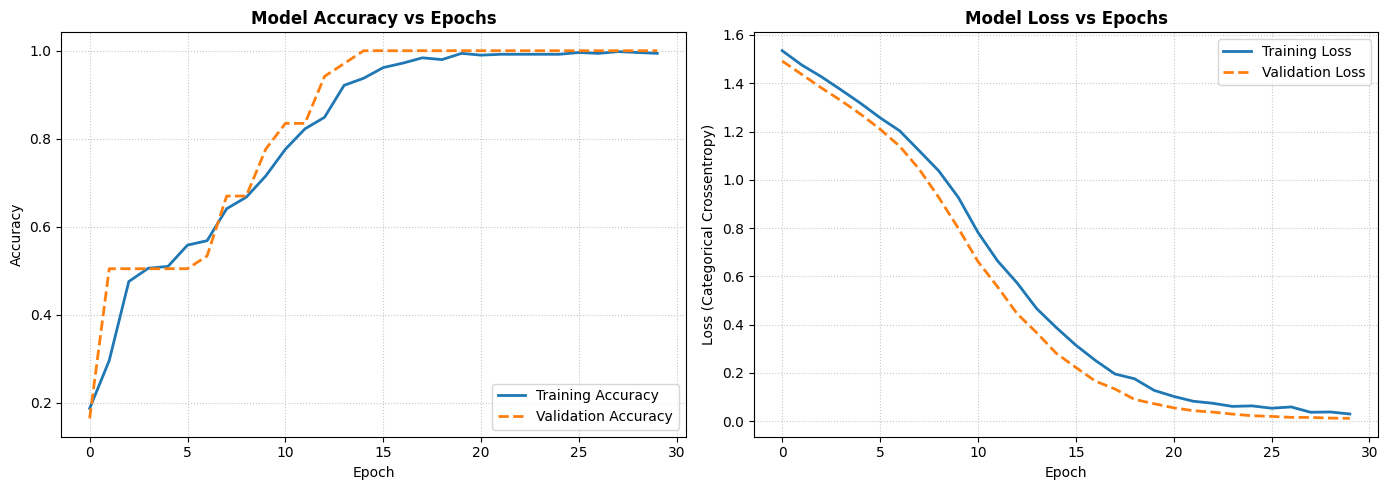


Generating Confusion Matrix for Test Set...


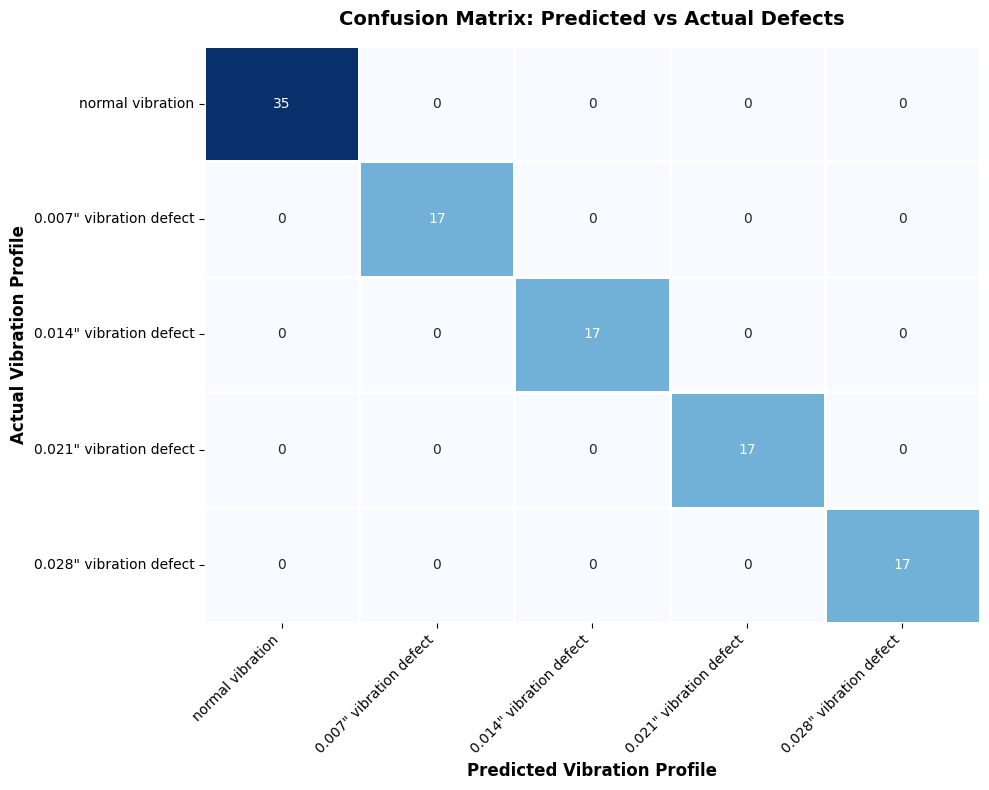

In [ ]:
# [CELL 7]
# 1. Training History Visualisations (Epoch vs Accuracy & Loss)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy vs Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle=':', alpha=0.7)

axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
axes[1].set_title('Model Loss vs Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (Categorical Crossentropy)')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# 2. Confusion Matrix
print("\nGenerating Confusion Matrix for Test Set...")

y_pred_probs = model.predict(X_test_n, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
class_labels = list(LABEL_MAP.values())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=1, linecolor='white')

plt.title('Confusion Matrix: Predicted vs Actual Defects', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Vibration Profile', fontsize=12, fontweight='bold')
plt.ylabel('Actual Vibration Profile', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()